# Quantitative Evaluation of 3D Hand Pose Estimation

This notebook computes MPJPE (Mean Per Joint Position Error), MPVPE (Mean Per Vertex Position Error), and 2D reprojection error for 3D hand poses generated by different optimization procedures. It uses labeled 2D hand poses as ground truth for evaluation.

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from collections import defaultdict

import cv2
from pycalib import triangulate

from helpers.definitions import *
from helpers.camera import load_camera_params, create_camera_matrix
from helpers.pose_construction import compute_reprojection_error

In [2]:
# Set File Paths for 2D Labeled and 3D Generated Poses

dataset = 'cha'  # dataset name
data_collections = [f'{dataset}/cha1', f'{dataset}/cha2', f'{dataset}/cha3', f'{dataset}/cha4', f'{dataset}/cha5', f'{dataset}/cha6', f'{dataset}/cha7']  # dataset collection name
data_collections_chb = [f'chb/chb1', f'chb/chb2']  # dataset collection name
data_collection_complexity = [0, 1, 1, 1, 0, 0, 0]
data_collection_complexity_chb = [2, 2]
# Path to labeled 2D hand poses (ground truth)

labeled_frames = list(range(0, 300, 30))

# Path to camera parameters (for reprojection)
camera_params_dir = f'camera_poses/{dataset}'

In [3]:
def detect_outliers(poses_3d, threshold=0.01, poses_2d=None, camera_params=None):
    """
    Detect outliers in 3D poses using bidirectional distance checks, Kalman filtering, 
    and optionally reprojection error for 2D poses.

    Args:
        poses_3d (np.ndarray): 3D poses for outlier detection (frames x keypoints x 3).
        threshold (float): Distance threshold for outlier detection (in meters).
        poses_2d (dict, optional): 2D poses for reprojection error calculation.
        camera_params (dict, optional): Camera parameters for reprojection.

    Returns:
        np.ndarray: Boolean array indicating outliers (True = outlier).
        np.ndarray: Smoothed 3D poses after Kalman filtering.
    """
    num_frames, num_keypoints, _ = poses_3d.shape
    outliers = np.zeros((num_frames, num_keypoints), dtype=bool)

    # Bidirectional distance-based outlier detection
    for frame_idx in range(1, num_frames - 1):
        for keypoint_idx in range(num_keypoints):
            if np.isnan(poses_3d[frame_idx, keypoint_idx]).any():
                outliers[frame_idx, keypoint_idx] = True
                continue

            # Compute distances to neighboring frames
            prev_dist = np.linalg.norm(
                poses_3d[frame_idx, keypoint_idx] - poses_3d[frame_idx - 1, keypoint_idx]
            )
            next_dist = np.linalg.norm(
                poses_3d[frame_idx, keypoint_idx] - poses_3d[frame_idx + 1, keypoint_idx]
            )

            # Mark as outlier if distance exceeds threshold
            if prev_dist > threshold or next_dist > threshold:
                outliers[frame_idx, keypoint_idx] = True

            if prev_dist > threshold and frame_idx == 1:
                outliers[frame_idx-1, keypoint_idx] = True
            if next_dist > threshold and frame_idx == num_frames - 2:
                outliers[frame_idx+1, keypoint_idx] = True

    # Replace outliers with NaN in 3D poses
    poses_3d[outliers] = np.nan

    return outliers, poses_3d

In [4]:
def load_data(data_collection):
    labeled_2d_path = f'final_labeled_poses/{data_collection}/hand_poses_2d_reprojected_expanded.npz'
    labeled_3d_path = f'final_labeled_poses/{data_collection}/hand_poses_3d.npz'
    # Dictionary of generated 3D hand pose files from different optimization methods
    # Key: method name, Value: file path
    hand_3d_pose_files = {
        'Triangulation': f'output_3d/{data_collection}/hand_poses_3d_triangulation_mapped.npz',
        'Temporal_Optimization': f'output_3d/{data_collection}/hand_poses_3d_temp_mapped.npz',
        'No-BMC_Optimization': f'output_3d/{data_collection}/hand_poses_3d_no_bmc_mapped.npz',
        'BMC_Optimization': f'output_3d/{data_collection}/hand_poses_3d_bmc_mapped.npz',
        'Ablation-wholebody-boxes': f'output_3d/{data_collection}/hand_poses_3d_ablation_wholebody_bboxes.npz',
        'Ablation-direct-wholebody': f'output_3d/{data_collection}/hand_poses_3d_ablation_direct_wholebody.npz'
    }

    # Load 2D annotations
    data_2d = np.load(labeled_2d_path, allow_pickle=True)
    unindexed_labeled_2d_poses = data_2d['poses_2d'].item() if 'poses_2d' in data_2d else data_2d[list(data_2d.keys())[0]].item()
    cam_names = list(unindexed_labeled_2d_poses.keys())
    labeled_2d_poses = {k: {cam_name: {} for cam_name in cam_names} for k in labeled_frames}
    for cam_name in cam_names:
        for frame_idx in labeled_frames:
            for obj_id in unindexed_labeled_2d_poses[cam_name][frame_idx].keys():
                keypoints = unindexed_labeled_2d_poses[cam_name][frame_idx][obj_id]['keypoints']
                scores = unindexed_labeled_2d_poses[cam_name][frame_idx][obj_id]['keypoint_scores']
                # Ensure keypoints and scores are numpy arrays
                labeled_2d_poses[frame_idx][cam_name][obj_id] = {'keypoints':np.array(keypoints), 'scores': np.array(scores)}
    print(f"Loaded labeled 2D hand poses for {len(labeled_2d_poses)} frames.")

    # Load 3D poses from labeled data
    labeled_3d_data = np.load(labeled_3d_path, allow_pickle=True)
    labeled_3d_poses = labeled_3d_data['poses_3d']
    

    # Load Generated 3D Hand Poses
    hand_3d_poses = {}
    for method, path in hand_3d_pose_files.items():
        try:
            data = np.load(path)
            # Assume the file contains 'poses_3d' key
            hand_3d_poses[method] = data['poses_3d']

            if labeled_frames:
                hand_3d_poses[method] = hand_3d_poses[method][labeled_frames]
            print(f"Loaded 3D hand poses for method '{method}': {hand_3d_poses[method].shape}")
        except:
            print(f"Failed to load 3D hand poses for method '{method}'")

    return labeled_2d_poses, labeled_3d_poses, hand_3d_poses


In [5]:
# Load camera parameters
cam_intrinsics, cam_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join(camera_params_dir, 'camera_intrinsics'),
    os.path.join(camera_params_dir, 'camera_extrinsics/aligned_poses.json'),
    suffix='_synced',
    named=True,
    import_extrinsics_matrix=True
)

In [6]:


# Function to triangulate 3D points from 2D observations
def triangulate_3d_poses(labeled_2d_poses, cam_intrinsics, cam_extrinsics, hand_3d_poses, score_threshold=0.5):
    """
    Triangulate 3D hand poses from labeled 2D poses across multiple cameras.
    
    Args:
        labeled_2d_poses: Dict of labeled 2D poses {frame_idx: {cam_name: {obj_id: {'keypoints': ndarray, 'scores': ndarray}}}}
        cam_intrinsics: Dict of camera intrinsic parameters
        cam_extrinsics: Dict of camera extrinsic parameters
        hand_3d_poses: Dict of 3D hand poses
        score_threshold: Minimum score for a keypoint to be considered valid
        
    Returns:
        Dict of triangulated 3D poses {frame_idx: {obj_id: 3D_pose_array}}
    """

    method = 'No-BMC_Optimization'  # Name of the triangulation method
    # Initialize results dictionary
    triangulated_3d_poses = np.zeros_like(hand_3d_poses[method])
    
    # Process each frame
    for out_idx, frame_idx in enumerate(labeled_2d_poses.keys()):
        
        # Get all object IDs in this frame
        all_obj_ids = [0, 1]
        # Process each object (hand)
        for obj_id in all_obj_ids:
            num_keypoints = None
            
            # Collect valid 2D observations for each keypoint across cameras
            valid_observations = defaultdict(list)
            valid_cameras = defaultdict(list)
            
            for cam_name in labeled_2d_poses[frame_idx].keys():
                if obj_id in labeled_2d_poses[frame_idx][cam_name].keys():
                    keypoints = labeled_2d_poses[frame_idx][cam_name][obj_id]['keypoints'].reshape(-1, 2)
                    scores = labeled_2d_poses[frame_idx][cam_name][obj_id]['scores'].flatten()
                    
                    if num_keypoints is None:
                        num_keypoints = keypoints.shape[0]
                        print(f"Number of keypoints detected: {num_keypoints}")
                    
                    # Store valid observations (score > threshold)
                    for i in range(num_keypoints):
                        if i < len(scores) and scores[i] > score_threshold:
                            valid_observations[i].append(keypoints[i])  # Store as [x, y]
                            valid_cameras[i].append(cam_name)
            
            # Triangulate each keypoint
            keypoints_3d = np.zeros((num_keypoints, 3)) if num_keypoints else np.array([])
            
            for kp_idx in range(num_keypoints):
                if kp_idx in valid_observations and len(valid_observations[kp_idx]) >= 2:
                    # Get projection matrices for cameras that see this keypoint
                    proj_matrices = []
                    points_2d = []
                    
                    for i, cam_name in enumerate(valid_cameras[kp_idx]):
                        proj_matrices.append(create_camera_matrix(cam_intrinsics[cam_name], cam_extrinsics[cam_name]))
                        points_2d.append(valid_observations[kp_idx][i])
                    
                    # Convert to the format required by cv2.triangulatePoints
                    proj_matrices = np.array(proj_matrices)
                    
                    # Simple triangulation using DLT if we have exactly 2 cameras
                    if len(proj_matrices) == 2:
                        points_2d = np.array(points_2d).T  # Shape: (2, n_cameras)
                        point_4d = cv2.triangulatePoints(proj_matrices[0], proj_matrices[1], 
                                                        points_2d[:, 0].reshape(2, 1), 
                                                        points_2d[:, 1].reshape(2, 1))
                        # Convert from homogeneous to 3D coordinates
                        point_3d = (point_4d / point_4d[3])[:3].ravel()
                        keypoints_3d[kp_idx] = point_3d
                    
                    # For more than 2 cameras, use an optimization approach
                    elif len(proj_matrices) > 2:
                        print(f"Triangulating keypoint {kp_idx} with {len(proj_matrices)} cameras and {len(points_2d)} detections.")
                        point_4d = triangulate(points_2d, proj_matrices)
                        point_3d = (point_4d / point_4d[3])[:3]
                        keypoints_3d[kp_idx] = point_3d
            
            # Store the triangulated 3D pose
            if obj_id == 0:
                triangulated_3d_poses[out_idx, :21] = keypoints_3d
            else:
                triangulated_3d_poses[out_idx, 21:] = keypoints_3d
    
    return triangulated_3d_poses

# Visualize a sample of the triangulated 3D poses
def visualize_3d_hand_pose(triangulated_poses_array):
    if len(triangulated_poses_array) > 0:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot the first pose
        sample_pose = triangulated_poses_array[0, 0:21]
        sample_pose_clean = []
        for i in range(len(sample_pose)):
            if np.all(sample_pose[i] == 0):
                sample_pose[i] = np.array([None, None, None])
            else:
                sample_pose_clean.append(sample_pose[i])
        sample_pose_clean = np.array(sample_pose_clean)
        ax.scatter(sample_pose_clean[:, 0], sample_pose_clean[:, 1], sample_pose_clean[:, 2], c='b', marker='o')
        
        # Connect keypoints to visualize hand skeleton (simplified)
        # Finger connections - adapt these based on your keypoint ordering
        connections = [
            (0, 1), (1, 2), (2, 3), (3, 4),       # Thumb
            (0, 5), (5, 6), (6, 7), (7, 8),       # Index finger
            (0, 9), (9, 10), (10, 11), (11, 12),  # Middle finger
            (0, 13), (13, 14), (14, 15), (15, 16), # Ring finger
            (0, 17), (17, 18), (18, 19), (19, 20)  # Pinky finger
        ]
        
        for start, end in connections:
            if sample_pose[start, 0] is not None and sample_pose[end, 0] is not None:
                if start < len(sample_pose) and end < len(sample_pose):
                    ax.plot([sample_pose[start, 0], sample_pose[end, 0]],
                            [sample_pose[start, 1], sample_pose[end, 1]],
                            [sample_pose[start, 2], sample_pose[end, 2]], 'r-')
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title('Triangulated 3D Hand Pose')
        
        # Set equal aspect ratio
        max_range = np.array([sample_pose_clean[:, 0].max() - sample_pose_clean[:, 0].min(),
                            sample_pose_clean[:, 1].max() - sample_pose_clean[:, 1].min(),
                            sample_pose_clean[:, 2].max() - sample_pose_clean[:, 2].min()]).max() / 2.0
        mid_x = (sample_pose_clean[:, 0].max() + sample_pose_clean[:, 0].min()) * 0.5
        mid_y = (sample_pose_clean[:, 1].max() + sample_pose_clean[:, 1].min()) * 0.5
        mid_z = (sample_pose_clean[:, 2].max() + sample_pose_clean[:, 2].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)
        
        plt.tight_layout()
        plt.show()


In [7]:
# Compute Mean Per Joint Position Error (MPJPE)
def compute_mpjpe(gt_3d, pred_3d):
    """Compute MPJPE between ground truth and predicted 3D hand poses."""
    # gt_3d, pred_3d: (N_frames, N_joints, 3)
    assert gt_3d.shape == pred_3d.shape
    masking_array = np.full(gt_3d.shape[:2], True)  # Initialize masking array
    for frame_idx in range(gt_3d.shape[0]):
        for joint_idx in range(gt_3d.shape[1]):
            if np.all(gt_3d[frame_idx, joint_idx] == 0) or np.all(np.isnan(gt_3d[frame_idx, joint_idx])) or np.all(pred_3d[frame_idx, joint_idx] == 0) or np.all(np.isnan(pred_3d[frame_idx, joint_idx])):
                masking_array[frame_idx, joint_idx] = False
                
    # Compute the error only for valid keypoints
    error = np.linalg.norm(gt_3d - pred_3d, axis=-1)  # (N_frames, N_joints)
    for frame_idx in range(gt_3d.shape[0]):
        for joint_idx in range(gt_3d.shape[1]):
            if np.isnan(error[frame_idx, joint_idx]) and masking_array[frame_idx, joint_idx]:
                print(f"NaN detected at frame {frame_idx}, joint {joint_idx}")
                print(gt_3d[frame_idx, joint_idx], pred_3d[frame_idx, joint_idx])
        
    error = error[masking_array]  # Filter out errors for missing keypoints
    return np.mean(error)



In [8]:
def mean_reprojection_error(pred_3d, labeled_2d_poses, cam_intrinsics, cam_extrinsics, distortion_coeffs):
    """
    Compute the mean reprojection error for predicted 3D poses against labeled 2D poses.
    
    Args:
        pred_3d: Predicted 3D poses (N_frames, N_joints, 3)
        labeled_2d_poses: Labeled 2D poses {frame_idx: {cam_name: {obj_id: {'keypoints': ndarray, 'scores': ndarray}}}}
        cam_intrinsics: Camera intrinsic parameters
        cam_extrinsics: Camera extrinsic parameters
        distortion_coeffs: Distortion coefficients
    
    Returns:
        Mean reprojection error in pixels.
    """
    reproj_errors = []
    for index, frame_idx in enumerate(labeled_2d_poses.keys()):

        pred_3d_frame = pred_3d[index]
        left_hand_3d = pred_3d_frame[:21]  # Assuming first 21 joints are left hand
        right_hand_3d = pred_3d_frame[21:]  # Assuming next 21 joints are right hand

        # Filter out NaN points in 3D predictions
        valid_left_mask = ~np.isnan(left_hand_3d).any(axis=1)
        valid_right_mask = ~np.isnan(right_hand_3d).any(axis=1)
            
        # Reshape labeled 2D poses for correct access to (num_cameras, num_keypoints -> (x,y) | None)
        left_hand_poses = {}
        right_hand_poses = {}
        for cam_name in labeled_2d_poses[frame_idx].keys():  
            for obj_id in labeled_2d_poses[frame_idx][cam_name].keys():
                keypoints = labeled_2d_poses[frame_idx][cam_name][obj_id]['keypoints'].reshape(-1, 2)
                scores = labeled_2d_poses[frame_idx][cam_name][obj_id]['scores'].flatten()
                masked_keypoints = [kp if score > 0.5 else None for (kp, score) in zip(keypoints, scores)]
                if obj_id == 0:
                    masked_keypoints = [kp for (kp, valid) in zip(masked_keypoints, valid_left_mask) if valid]
                    assert(len(masked_keypoints) == sum(valid_left_mask))
                    left_hand_poses[cam_name] = masked_keypoints
                elif obj_id == 1:
                    masked_keypoints = [kp for (kp, valid) in zip(masked_keypoints, valid_right_mask) if valid]
                    assert(len(masked_keypoints) == sum(valid_right_mask))
                    right_hand_poses[cam_name] = masked_keypoints

        pred_3d_frame = pred_3d[index]
        left_hand_3d = pred_3d_frame[:21]  # Assuming first 21 joints are left hand
        right_hand_3d = pred_3d_frame[21:]  # Assuming next 21 joints are right hand

        # Filter out NaN points in 3D predictions
        valid_left_mask = ~np.isnan(left_hand_3d).any(axis=1)
        valid_right_mask = ~np.isnan(right_hand_3d).any(axis=1)

        # Compute reprojection error only for valid 3D points
        if np.any(valid_left_mask):
            reproj_errors.append(compute_reprojection_error(
                left_hand_3d[valid_left_mask], left_hand_poses, cam_intrinsics, cam_extrinsics, distortion_coeffs, named=True))
        if np.any(valid_right_mask):
            reproj_errors.append(compute_reprojection_error(
                right_hand_3d[valid_right_mask], right_hand_poses, cam_intrinsics, cam_extrinsics, distortion_coeffs, named=True))
        
    if reproj_errors:
        mean_reproj_error = np.mean(reproj_errors)
        print(f"Reprojection errors for {len(reproj_errors)} frames: {reproj_errors}")
        print(f"Mean reprojection error: {mean_reproj_error} px")
        return mean_reproj_error
    else:
        return None


In [9]:
def report_results(labeled_2d_poses, labeled_3d_poses, hand_3d_poses):
    # Use the function to triangulate 3D poses
    # labeled_3d_poses = triangulate_3d_poses(labeled_2d_poses, cam_intrinsics, cam_extrinsics, hand_3d_poses)
    # print(f"Triangulated 3D poses: {labeled_3d_poses}")

    # # Convert to the same format as hand_3d_poses for compariso
    # triangulated_poses_array = np.array(labeled_3d_poses)
    # print(f"Triangulated 3D poses shape: {triangulated_poses_array.shape}")

    # Compute Reprojection Error
    reproj_results = {}
    for method, pred_3d in hand_3d_poses.items():
        reproj_error = mean_reprojection_error(pred_3d, labeled_2d_poses, cam_intrinsics, cam_extrinsics, distortion_coeffs)
        reproj_results[method] = reproj_error
        print(f"Reprojection error for {method}: {reproj_error:.2f} px" if reproj_error is not None else f"Reprojection error for {method}: N/A")

    # For now, set gt_3d_poses = pred_3d_poses for demonstration
    mpjpe_results = {}
    for method, pred_3d in hand_3d_poses.items():
        # Replace the next line with actual ground truth 3D poses if available
        gt_3d = labeled_3d_poses
        mpjpe = compute_mpjpe(gt_3d, pred_3d) # Compute MPJPE in meters
        # Convert MPJPE to millimeters
        mpjpe *= 1000  # Convert from meters to millimeters
        # Store the MPJPE result
        mpjpe_results[method] = mpjpe
        print(f"MPJPE for {method}: {mpjpe:.2f} mm")

    results = []
    for method in hand_3d_poses:
        results.append({
            'Method': method,
            'MPJPE (mm)': mpjpe_results.get(method, None),
            'Reprojection Error (px)': reproj_results.get(method, None)
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    return results


Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-wholebody-boxes': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-direct-wholebody': (10, 42, 3)
Reprojection errors for 20 frames: [6.172158089941298, 6.277657419289843, 6.801981404428207, 5.047474686504291, 8.75820460648897, 5.798250417049317, 6.220838139986424, 5.440762301025196, 6.36600929031134, 6.3032179816361396, 5.780534294890993, 6.044763763289331, 5.948589624324117, 6.372231314079177, 15.891847526630828, 6.9829927335373245, 4.912301121897654, 77.47128644522303, 7.227880081504768, 22.95993126557397]
Mean reprojection error: 11.138945625380611 px
Reprojection error for Triangulation: 11.14 px
Reprojection errors for 20 frames: [5.4

,Method,MPJPE (mm),Reprojection Error (px)
0,Triangulation,19.345556,11.138946
1,Temporal_Optimization,8.508155,6.039074
2,No-BMC_Optimization,8.327574,6.040139
3,BMC_Optimization,10.154883,7.823748
4,Ablation-wholebody-boxes,10.444176,7.787160
5,Ablation-direct-wholebody,17.120149,15.642249


Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-wholebody-boxes': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-direct-wholebody': (10, 42, 3)
Reprojection errors for 20 frames: [29.23594487075706, 46.50826861666199, 31.58012016879262, 25.63005843331348, 7.248581605678155, 86.26636488770104, 5.029291469195149, 44.416702096527736, 7.153526793543897, 136.03786748505428, 7.458884085240953, 661.8438947012372, 10.12302618890299, 0.0, 6.990431697382457, 9.092090670662435, 7.7463158591311, 9.84263634428967, 9.550131393549199, 6.992300533919596]
Mean reprojection error: 57.43732189507706 px
Reprojection error for Triangulation: 57.44 px
Reprojection errors for 20 frames: [6.575214443643715, 8

,Method,MPJPE (mm),Reprojection Error (px)
0,Triangulation,64.484888,57.437322
1,Temporal_Optimization,9.050237,7.740663
2,No-BMC_Optimization,9.118420,8.181921
3,BMC_Optimization,15.947629,12.731499
4,Ablation-wholebody-boxes,23.296937,20.144835
5,Ablation-direct-wholebody,17.283358,16.648343


Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-wholebody-boxes': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-direct-wholebody': (10, 42, 3)
Reprojection errors for 20 frames: [5.684584011506022, 179.69882090494048, 6.553544172971753, 90.47288333720628, 4.163247571689962, 202.36761794419996, 8.163024488948265, 205.72257886263358, 62.32361773533665, 17.435881685918538, 53.228485863867775, 11.562353111720135, 34.21887891210207, 4.756934097415459, 33.9262280209125, 4.696118706746603, 52.55409272976479, 5.210877434945953, 38.10034720981839, 6.460651291711282]
Mean reprojection error: 51.36503840471782 px
Reprojection error for Triangulation: 51.37 px
Reprojection errors for 20 frames: [

...

,Method,MPJPE (mm),Reprojection Error (px)
0,No-BMC_Optimization,8.155487,6.873367
1,Triangulation,132.561745,80.783826
2,Ablation-wholebody-boxes,49.271553,54.825449
3,Temporal_Optimization,8.085838,6.843457
4,Ablation-direct-wholebody,15.914336,15.681270
5,BMC_Optimization,11.834976,9.219492


L1 Results:


,Method,MPJPE (mm),Reprojection Error (px)
0,No-BMC_Optimization,9.146767,8.657431
1,Triangulation,47.642851,51.719315
2,Ablation-wholebody-boxes,21.612161,21.056406
3,Temporal_Optimization,8.807272,8.256274
4,Ablation-direct-wholebody,17.674628,16.269399
5,BMC_Optimization,14.365576,13.202897


L2 Results:


,Method,MPJPE (mm),Reprojection Error (px)
0,No-BMC_Optimization,NaN,NaN
1,Triangulation,NaN,NaN
2,Ablation-wholebody-boxes,NaN,NaN
3,Temporal_Optimization,NaN,NaN
4,Ablation-direct-wholebody,NaN,NaN
5,BMC_Optimization,NaN,NaN


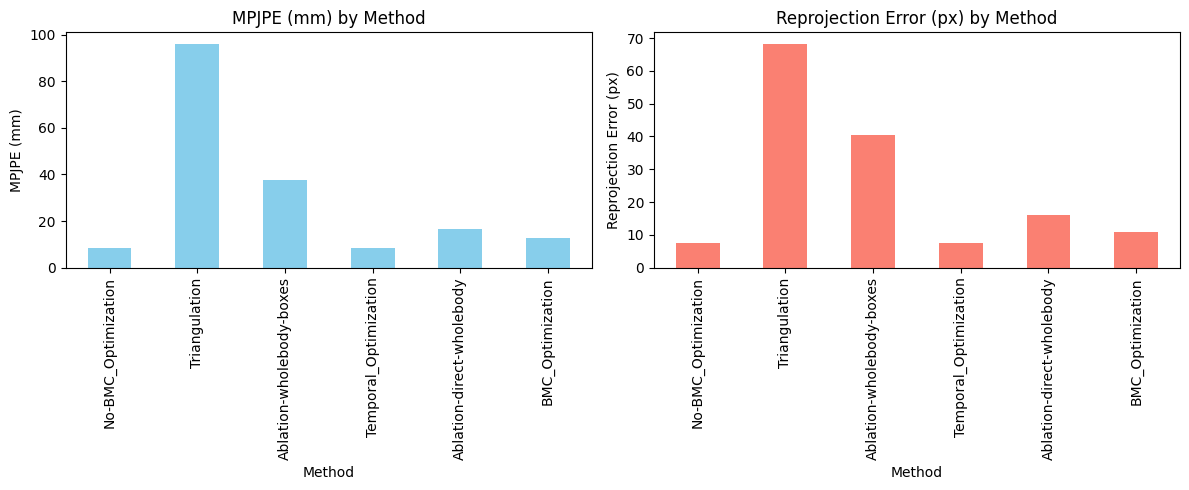

In [ ]:
results = []
methods = set()

# Load camera parameters
cam_intrinsics, cam_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join(camera_params_dir, 'camera_intrinsics'),
    os.path.join(camera_params_dir, 'camera_extrinsics/aligned_poses.json'),
    suffix='_synced',
    named=True,
    import_extrinsics_matrix=True
)

for data_collection in data_collections:
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)

    methods.update({method for method in hand_3d_poses.keys()})
    results.append(report_results(labeled_2d_poses, labeled_3d_poses, hand_3d_poses))


# Load camera parameters
cam_names.pop()
cam_intrinsics, cam_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join("camera_poses", "chb", 'camera_intrinsics'),
    os.path.join("camera_poses", "chb", 'camera_extrinsics/aligned_poses.json'),
    suffix='',
    named=True,
    import_extrinsics_matrix=True
)
for data_collection in data_collections_chb:
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    methods.update({method for method in hand_3d_poses.keys()})
    results.append(report_results(labeled_2d_poses, labeled_3d_poses, hand_3d_poses))

def summarize_results(results):
    full_results = []
    for method in methods:
        mpjpes = []
        reproj = []
        for r in results:
            for mr in r:
                if mr['Method'] == method:
                    mpjpes.append(mr['MPJPE (mm)'])
                    reproj.append(mr['Reprojection Error (px)'])
        full_results.append({
            'Method': method,
            'MPJPE (mm)': np.mean(mpjpes),
            'Reprojection Error (px)': np.mean(reproj)
        })
    return full_results

full_results = summarize_results(results)
results_df = pd.DataFrame(full_results)

print("Full Results:")
display(results_df)

L0_results = pd.DataFrame(summarize_results([results[0]] + results[4:8]))
L1_results = pd.DataFrame(summarize_results(results[1:4]))
L2_results = pd.DataFrame(summarize_results(results[8:]))

print("L0 Results:")
display(L0_results)

print("L1 Results:")
display(L1_results)

print("L2 Results:")
display(L2_results)

# Bar plot for MPJPE and Reprojection Error
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
results_df.plot(x='Method', y='MPJPE (mm)', kind='bar', ax=ax[0], legend=False, color='skyblue')
ax[0].set_title('MPJPE (mm) by Method')
ax[0].set_ylabel('MPJPE (mm)')
results_df.plot(x='Method', y='Reprojection Error (px)', kind='bar', ax=ax[1], legend=False, color='salmon')
ax[1].set_title('Reprojection Error (px) by Method')
ax[1].set_ylabel('Reprojection Error (px)')
plt.tight_layout()
plt.show()

cam_names.append('gopro12')

## Reprojection Threshold Analysis

This section analyzes the percentage of keypoints that fall within different reprojection error thresholds. This provides insight into the distribution of reprojection errors and helps understand method performance at different precision levels.

In [11]:
# Reprojection Threshold Analysis
def compute_reprojection_accuracy_at_thresholds(pred_3d, labeled_2d_poses, cam_intrinsics, cam_extrinsics, distortion_coeffs, thresholds=[5, 10, 15, 20]):
    """
    Compute the percentage of keypoints that fall within different reprojection error thresholds.
    
    Args:
        pred_3d: Predicted 3D poses (N_frames, N_joints, 3)
        labeled_2d_poses: Labeled 2D poses {frame_idx: {cam_name: {obj_id: {'keypoints': ndarray, 'scores': ndarray}}}}
        cam_intrinsics: Camera intrinsic parameters
        cam_extrinsics: Camera extrinsic parameters
        distortion_coeffs: Distortion coefficients
        thresholds: List of pixel thresholds to evaluate
    
    Returns:
        Dictionary with percentage of keypoints within each threshold
    """
    from helpers.camera import project_points
    
    all_errors = []
    
    for index, frame_idx in enumerate(labeled_2d_poses.keys()):
        # Reshape labeled 2D poses for correct access
        left_hand_poses = {}
        right_hand_poses = {}
        
        for cam_name in cam_names:  
            if cam_name in labeled_2d_poses[frame_idx] and labeled_2d_poses[frame_idx][cam_name]:
                for obj_id in labeled_2d_poses[frame_idx][cam_name].keys():
                    keypoints = labeled_2d_poses[frame_idx][cam_name][obj_id]['keypoints'].reshape(-1, 2)
                    scores = labeled_2d_poses[frame_idx][cam_name][obj_id]['scores'].flatten()
                    
                    if obj_id == 0:
                        left_hand_poses[cam_name] = {'keypoints': keypoints, 'scores': scores}
                    elif obj_id == 1:
                        right_hand_poses[cam_name] = {'keypoints': keypoints, 'scores': scores}

        pred_3d_frame = pred_3d[index]
        left_hand_3d = pred_3d_frame[:21]  # First 21 joints are left hand
        right_hand_3d = pred_3d_frame[21:]  # Next 21 joints are right hand

        # Filter out NaN points in 3D predictions
        valid_left_mask = ~np.isnan(left_hand_3d).any(axis=1)
        valid_right_mask = ~np.isnan(right_hand_3d).any(axis=1)

        # Compute errors for left hand
        for cam_name in left_hand_poses:
            if cam_name in cam_intrinsics:
                # Project 3D to 2D
                try:
                    proj_2d = project_points(
                        left_hand_3d,
                        cam_intrinsics[cam_name],
                        cam_extrinsics[cam_name][0],  # rotation
                        cam_extrinsics[cam_name][1],  # translation
                        distortion_coeffs[cam_name]
                    )
                    
                    gt_2d = left_hand_poses[cam_name]['keypoints']
                    scores = left_hand_poses[cam_name]['scores']
                    
                    # Only consider keypoints with score > 0.5
                    valid_mask = scores > 0.5
                    valid_mask = valid_mask & valid_left_mask
                    
                    if np.any(valid_mask) and len(proj_2d) == len(gt_2d):
                        errors = np.linalg.norm(proj_2d[valid_mask] - gt_2d[valid_mask], axis=1)
                        all_errors.extend(errors)
                except Exception as e:
                    print(f"Error projecting left hand for {cam_name}: {e}")
                    continue

        # Compute errors for right hand
        for cam_name in right_hand_poses:
            if cam_name in cam_intrinsics:
                # Project 3D to 2D
                try:
                    proj_2d = project_points(
                        right_hand_3d,
                        cam_intrinsics[cam_name],
                        cam_extrinsics[cam_name][0],  # rotation
                        cam_extrinsics[cam_name][1],  # translation
                        distortion_coeffs[cam_name]
                    )
                    
                    gt_2d = right_hand_poses[cam_name]['keypoints']
                    scores = right_hand_poses[cam_name]['scores']
                    
                    # Only consider keypoints with score > 0.5
                    valid_mask = scores > 0.5
                    valid_mask = valid_mask & valid_right_mask
                    
                    if np.any(valid_mask) and len(proj_2d) == len(gt_2d):
                        errors = np.linalg.norm(proj_2d[valid_mask] - gt_2d[valid_mask], axis=1)
                        all_errors.extend(errors)
                except Exception as e:
                    print(f"Error projecting right hand for {cam_name}: {e}")
                    continue
    
    # Calculate percentage of keypoints within each threshold
    threshold_results = {}
    all_errors = np.array(all_errors)
    
    if len(all_errors) > 0:
        for threshold in thresholds:
            percentage = (np.sum(all_errors <= threshold) / len(all_errors)) * 100
            threshold_results[f'{threshold}px'] = percentage
    else:
        for threshold in thresholds:
            threshold_results[f'{threshold}px'] = 0.0
    
    return threshold_results, all_errors

def report_results_2(hand_3d_poses, labeled_2d_poses, thresholds):
    # Compute threshold analysis for each method
    threshold_results = {}
    all_errors_by_method = {}

    print("=== Reprojection Threshold Analysis ===")
    for method, pred_3d in hand_3d_poses.items():
        print(f"\nAnalyzing {method}...")
        results, errors = compute_reprojection_accuracy_at_thresholds(
            pred_3d, labeled_2d_poses, cam_intrinsics, cam_extrinsics, distortion_coeffs, thresholds
        )
        threshold_results[method] = results
        all_errors_by_method[method] = errors
        
        print(f"  Total keypoints analyzed: {len(errors)}")
        for threshold_key, percentage in results.items():
            print(f"  Keypoints within {threshold_key}: {percentage:.1f}%")

    return all_errors_by_method, threshold_results

Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-wholebody-boxes': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-direct-wholebody': (10, 42, 3)
=== Reprojection Threshold Analysis ===

Analyzing Triangulation...
  Total keypoints analyzed: 1339
  Keypoints within 5px: 48.0%
  Keypoints within 10px: 83.7%
  Keypoints within 20px: 94.9%
  Keypoints within 30px: 97.6%

Analyzing Temporal_Optimization...
  Total keypoints analyzed: 1339
  Keypoints within 5px: 50.0%
  Keypoints within 10px: 86.3%
  Keypoints within 20px: 99.0%
  Keypoints within 30px: 99.7%

Analyzing No-BMC_Optimization...
  Total keypoints analyzed: 1339
  Keypoints within 5px: 51.5%
  Keypoints within 10px: 85.0%
  Keyp

,Method,5px,10px,20px,30px,Mean Reconstruction Percentage
0,Triangulation,34.301827,62.226726,77.893301,81.819035,64.060222
1,Temporal_Optimization,42.204114,77.167413,96.747571,99.170021,78.822280
2,No-BMC_Optimization,41.106290,75.597457,96.129116,99.130152,77.990754
3,BMC_Optimization,34.517759,65.481926,88.899422,94.811779,70.927722
4,Ablation-wholebody-boxes,22.554821,48.107195,67.851460,74.219789,53.183316
5,Ablation-direct-wholebody,8.864140,30.835376,70.065747,90.343136,50.027100


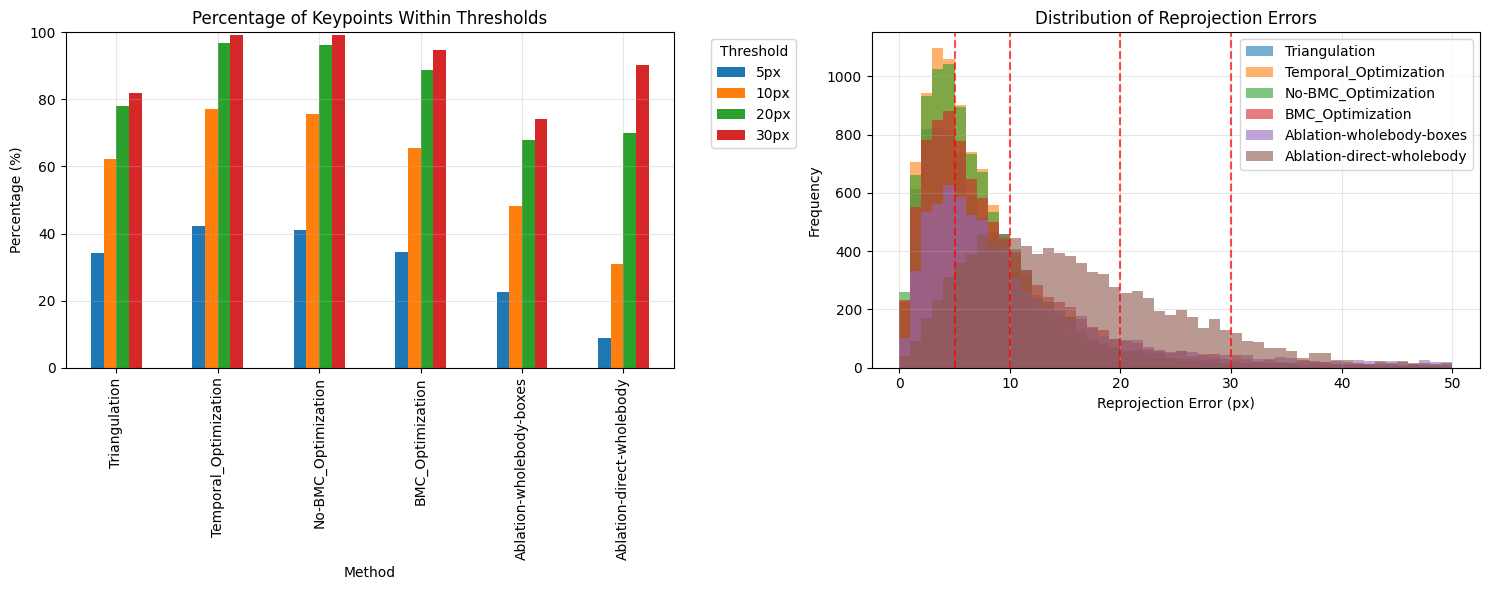


=== Reprojection Error Statistics (Averaged Across Data Collections) ===
{'Triangulation': {'cha/cha1': 81.06796116504854, 'cha/cha2': 65.77885391444714, 'cha/cha3': 55.0, 'cha/cha4': 75.94019728729964, 'cha/cha5': 49.96153846153847, 'cha/cha6': 65.143299767622, 'cha/cha7': 55.52970651395849}, 'Temporal_Optimization': {'cha/cha1': 83.75653472740852, 'cha/cha2': 76.29136400322841, 'cha/cha3': 77.02952029520296, 'cha/cha4': 77.45067817509249, 'cha/cha5': 77.6923076923077, 'cha/cha6': 78.73741285824941, 'cha/cha7': 80.79813886900502}, 'No-BMC_Optimization': {'cha/cha1': 83.7565347274085, 'cha/cha2': 74.59644874899112, 'cha/cha3': 74.92619926199262, 'cha/cha4': 76.03267570900123, 'cha/cha5': 77.92307692307692, 'cha/cha6': 78.81487219209914, 'cha/cha7': 79.88546886184682}, 'BMC_Optimization': {'cha/cha1': 76.32561613144138, 'cha/cha2': 62.30831315577078, 'cha/cha3': 67.47232472324723, 'cha/cha4': 65.47472256473489, 'cha/cha5': 73.07692307692308, 'cha/cha6': 74.67079783113866, 'cha/cha7': 7

In [ ]:
# Aggregate reprojection threshold analysis across all data collections
threshold_results_aggregated = {}
all_errors_aggregated = {}
mean_pck = {}

# Load camera parameters
cam_intrinsics, cam_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join(camera_params_dir, 'camera_intrinsics'),
    os.path.join(camera_params_dir, 'camera_extrinsics/aligned_poses.json'),
    suffix='_synced',
    named=True,
    import_extrinsics_matrix=True
)

for data_collection in data_collections:
    # Define thresholds to evaluate
    thresholds = [5, 10, 20, 30] # in pixels
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    all_errors_by_method, threshold_results = report_results_2(hand_3d_poses, labeled_2d_poses, thresholds)

    for method, results in threshold_results.items():
        percentages = []
        for threshold, percentage in results.items():
            if (method, threshold) not in threshold_results_aggregated:
                threshold_results_aggregated[(method, threshold)] = []
            threshold_results_aggregated[(method, threshold)].append(percentage)
            percentages.append(percentage)

        if method not in mean_pck:
            mean_pck[method] = {}
        mean_pck[method][data_collection] = np.mean(percentages) if len(percentages) > 0 else np.nan

    for method, errors in all_errors_by_method.items():
        if method not in all_errors_aggregated:
            all_errors_aggregated[method] = []
        all_errors_aggregated[method].extend(errors)

# Load camera parameters
cam_names.pop()
cam_intrinsics, cam_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join("camera_poses", "chb", 'camera_intrinsics'),
    os.path.join("camera_poses", "chb", 'camera_extrinsics/aligned_poses.json'),
    suffix='',
    named=True,
    import_extrinsics_matrix=True
)
for data_collection in data_collections_chb:
    # Define thresholds to evaluate
    thresholds = [5, 10, 20, 30] # in pixels
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    all_errors_by_method, threshold_results = report_results_2(hand_3d_poses, labeled_2d_poses, thresholds)
    for method, results in threshold_results.items():
        percentages = []
        for threshold, percentage in results.items():
            if (method, threshold) not in threshold_results_aggregated:
                threshold_results_aggregated[(method, threshold)] = []
            threshold_results_aggregated[(method, threshold)].append(percentage)
            percentages.append(percentage)
        if method not in mean_pck:
            mean_pck[method] = {}
        mean_pck[method][data_collection] = np.mean(percentages) if len(percentages) > 0 else np.nan
    for method, errors in all_errors_by_method.items():
        if method not in all_errors_aggregated:
            all_errors_aggregated[method] = []
        all_errors_aggregated[method].extend(errors)


# Average the results across all data collections
threshold_results_avg = {}
for (method, threshold), percentages in threshold_results_aggregated.items():
    if method not in threshold_results_avg:
        threshold_results_avg[method] = {}
    threshold_results_avg[method][threshold] = np.mean(percentages)

method_mean_reconstruction_percentage = {}
for method, values in threshold_results_avg.items():
    method_mean_reconstruction_percentage[method] = np.mean(list(values.values()))

# Create threshold analysis results table
threshold_df_data = []
for method in threshold_results_avg:
    row = {'Method': method}
    row.update(threshold_results_avg[method])
    row.update({'Mean Reconstruction Percentage': method_mean_reconstruction_percentage[method]})
    threshold_df_data.append(row)

threshold_df = pd.DataFrame(threshold_df_data)
print("\n=== Percentage of Keypoints Within Reprojection Thresholds (Averaged Across Data Collections) ===")
display(threshold_df)

def summarize_results_df(results):
    full_results = []
    for method in methods:
        mpjpes = []
        reproj = []
        for r in results:
            for mr in r:
                if mr['Method'] == method:
                    mpjpes.append(mr['MPJPE (mm)'])
                    reproj.append(mr['Reprojection Error (px)'])
        full_results.append({
            'Method': method,
            'MPJPE (mm)': np.mean(mpjpes),
            'Reprojection Error (px)': np.mean(reproj)
        })
    return full_results

# Visualization of threshold analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot showing percentage within each threshold
threshold_cols = [f'{t}px' for t in thresholds]
threshold_df.set_index('Method')[threshold_cols].plot(kind='bar', ax=axes[0], 
                                                     title='Percentage of Keypoints Within Thresholds',
                                                     ylabel='Percentage (%)',
                                                     xlabel='Method')
axes[0].legend(title='Threshold', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

# Error distribution histograms
for method, errors in all_errors_aggregated.items():
    if len(errors) > 0:
        axes[1].hist(errors, bins=50, alpha=0.6, label=method, range=(0, 50))

axes[1].set_xlabel('Reprojection Error (px)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Reprojection Errors')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add vertical lines for thresholds
for threshold in thresholds:
    axes[1].axvline(x=threshold, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Reprojection Error Statistics (Averaged Across Data Collections) ===")
stats_data = []
for method, errors in all_errors_aggregated.items():
    if len(errors) > 0:
        stats_data.append({
            'Method': method,
            'Mean Error (px)': np.mean(errors),
            'Median Error (px)': np.median(errors),
            'Std Error (px)': np.std(errors),
            'Min Error (px)': np.min(errors),
            'Max Error (px)': np.max(errors),
            '95th Percentile (px)': np.percentile(errors, 95)
        })

print(mean_pck)

In [14]:
L0_threshold_results = {}
L1_threshold_results = {}
L2_threshold_results = {}

for k, v in threshold_results_aggregated.items():
    L0_threshold_results[k] = np.mean([[v[0]] + v[4:8]])
    L1_threshold_results[k] = np.mean([v[1:4]])
    L2_threshold_results[k] = np.mean(v[8:])

L0_threshold_results_data = {}
L1_threshold_results_data = {}
L2_threshold_results_data = {}
columns = ['5px', '10px', '20px', '30px']
for k, v in L0_threshold_results.items():
    L0_threshold_results_data.setdefault(k[0], []).append(v) 

for k, v in L1_threshold_results.items():
    L1_threshold_results_data.setdefault(k[0], []).append(v) 

for k, v in L2_threshold_results.items():
    L2_threshold_results_data.setdefault(k[0], []).append(v) 

print("\n=== Percentage of Keypoints Within Reprojection Thresholds (Averaged Across Data Collections) ===")
display(threshold_df)

L0_threshold_results_data_df = pd.DataFrame.from_dict(L0_threshold_results_data, orient='index', columns=columns)
L0_threshold_results_data_df["Mean Reconstruction Percentage"] =  L0_threshold_results_data_df[["5px", "10px", "20px", "30px"]].mean(axis=1)
print("L0 Results:")
display(L0_threshold_results_data_df)

L1_threshold_results_data_df = pd.DataFrame.from_dict(L1_threshold_results_data, orient='index', columns=columns)
L1_threshold_results_data_df["Mean Reconstruction Percentage"] =  L1_threshold_results_data_df[["5px", "10px", "20px", "30px"]].mean(axis=1)
print("L1 Results:")
display(L1_threshold_results_data_df)

L2_threshold_results_data_df = pd.DataFrame.from_dict(L2_threshold_results_data, orient='index', columns=columns)
L2_threshold_results_data_df["Mean Reconstruction Percentage"] =  L2_threshold_results_data_df[["5px", "10px", "20px", "30px"]].mean(axis=1)
print("L2 Results:")
display(L2_threshold_results_data_df)


=== Percentage of Keypoints Within Reprojection Thresholds (Averaged Across Data Collections) ===


c:\Users\hofn\AppData\Local\miniconda3\envs\orpose\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\hofn\AppData\Local\miniconda3\envs\orpose\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,Method,5px,10px,20px,30px,Mean Reconstruction Percentage
0,Triangulation,34.301827,62.226726,77.893301,81.819035,64.060222
1,Temporal_Optimization,42.204114,77.167413,96.747571,99.170021,78.822280
2,No-BMC_Optimization,41.106290,75.597457,96.129116,99.130152,77.990754
3,BMC_Optimization,34.517759,65.481926,88.899422,94.811779,70.927722
4,Ablation-wholebody-boxes,22.554821,48.107195,67.851460,74.219789,53.183316
5,Ablation-direct-wholebody,8.864140,30.835376,70.065747,90.343136,50.027100


L0 Results:


,5px,10px,20px,30px,Mean Reconstruction Percentage
Triangulation,34.929695,62.805895,75.597161,78.369755,62.925626
Temporal_Optimization,43.969675,79.429766,97.981486,99.603467,80.246099
No-BMC_Optimization,44.233843,78.552531,97.835915,99.757663,80.094988
BMC_Optimization,38.654857,71.665386,93.528465,97.389984,75.309673
Ablation-wholebody-boxes,16.561358,37.349057,55.134333,61.677904,42.680663
Ablation-direct-wholebody,8.723643,31.036611,72.410978,92.364926,51.134039


L1 Results:


,5px,10px,20px,30px,Mean Reconstruction Percentage
Triangulation,33.464670,61.454500,80.954822,86.418075,65.573017
Temporal_Optimization,39.850032,74.150942,95.102351,98.592092,76.923854
No-BMC_Optimization,36.936219,71.657357,93.853383,98.293472,75.185108
BMC_Optimization,29.001629,57.237312,82.727366,91.374174,65.085120
Ablation-wholebody-boxes,30.546106,62.451377,84.807629,90.942302,67.186854
Ablation-direct-wholebody,9.051471,30.567063,66.938773,87.647416,48.551180


L2 Results:


,5px,10px,20px,30px,Mean Reconstruction Percentage
Triangulation,NaN,NaN,NaN,NaN,NaN
Temporal_Optimization,NaN,NaN,NaN,NaN,NaN
No-BMC_Optimization,NaN,NaN,NaN,NaN,NaN
BMC_Optimization,NaN,NaN,NaN,NaN,NaN
Ablation-wholebody-boxes,NaN,NaN,NaN,NaN,NaN
Ablation-direct-wholebody,NaN,NaN,NaN,NaN,NaN


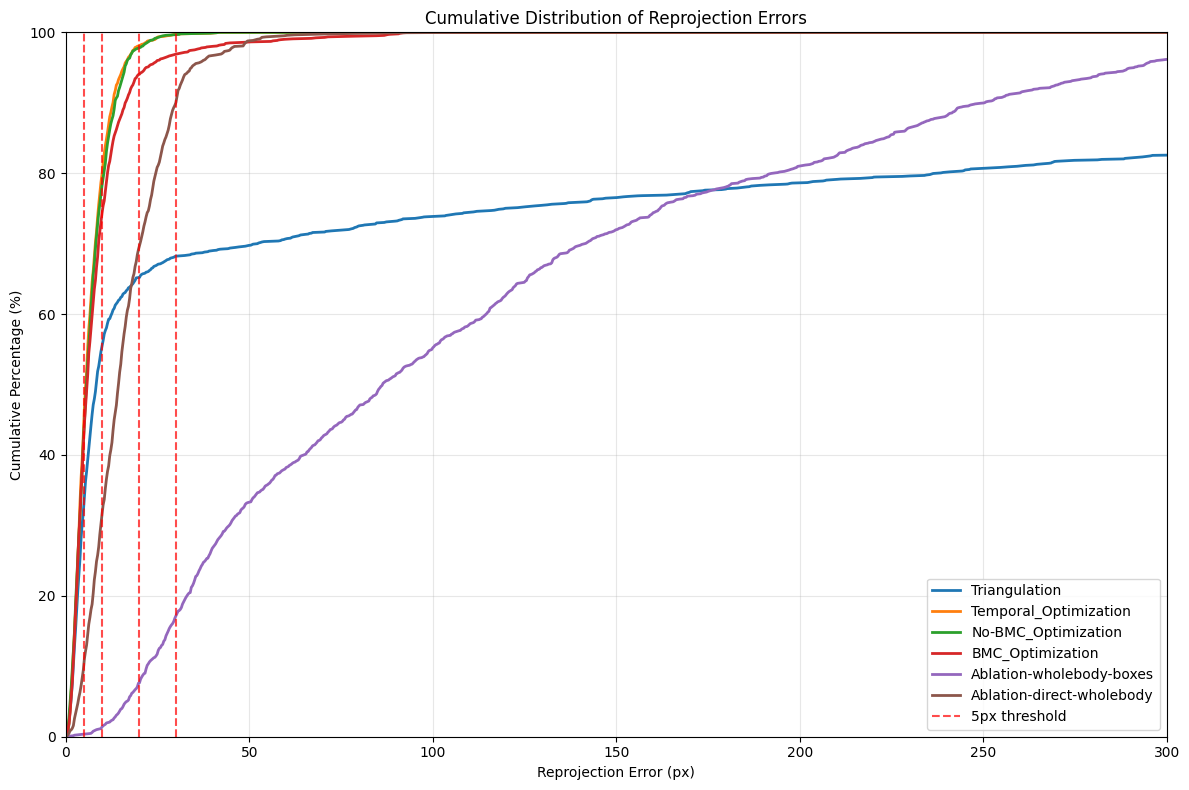


=== Comparative Analysis at Key Thresholds ===

At 5px threshold:
  1. Temporal_Optimization: 45.2%
  2. No-BMC_Optimization: 43.9%
  3. BMC_Optimization: 43.2%
  4. Triangulation: 33.1%
  5. Ablation-direct-wholebody: 10.5%
  6. Ablation-wholebody-boxes: 0.4%

At 10px threshold:
  1. Temporal_Optimization: 80.2%
  2. No-BMC_Optimization: 78.2%
  3. BMC_Optimization: 74.6%
  4. Triangulation: 55.7%
  5. Ablation-direct-wholebody: 31.6%
  6. Ablation-wholebody-boxes: 1.4%

At 20px threshold:
  1. Temporal_Optimization: 98.1%
  2. No-BMC_Optimization: 97.8%
  3. BMC_Optimization: 94.0%
  4. Ablation-direct-wholebody: 69.4%
  5. Triangulation: 65.1%
  6. Ablation-wholebody-boxes: 7.6%

At 30px threshold:
  1. Temporal_Optimization: 99.7%
  2. No-BMC_Optimization: 99.6%
  3. BMC_Optimization: 96.9%
  4. Ablation-direct-wholebody: 90.0%
  5. Triangulation: 68.2%
  6. Ablation-wholebody-boxes: 17.1%

=== Best Performing Method at Each Threshold ===
At 5px: Temporal_Optimization (45.2%)
At 1

In [15]:
# Cumulative Distribution Function (CDF) Analysis
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

max_error_to_plot = 300  # Focus on errors up to 300 pixels
x_values = np.linspace(0, max_error_to_plot, 1000)

for method, errors in all_errors_by_method.items():
    if len(errors) > 0:
        # Calculate CDF
        errors_sorted = np.sort(errors)
        cdf_values = np.arange(1, len(errors_sorted) + 1) / len(errors_sorted) * 100
        
        # Interpolate for smooth curve
        cdf_interp = np.interp(x_values, errors_sorted, cdf_values)
        ax.plot(x_values, cdf_interp, label=method, linewidth=2)

# Add threshold lines
for threshold in thresholds:
    ax.axvline(x=threshold, color='red', linestyle='--', alpha=0.7, 
               label=f'{threshold}px threshold' if threshold == thresholds[0] else '')

ax.set_xlabel('Reprojection Error (px)')
ax.set_ylabel('Cumulative Percentage (%)')
ax.set_title('Cumulative Distribution of Reprojection Errors')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_error_to_plot)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Comparative analysis at specific thresholds
print("\n=== Comparative Analysis at Key Thresholds ===")
for threshold in thresholds:
    print(f"\nAt {threshold}px threshold:")
    threshold_key = f'{threshold}px'
    
    # Sort methods by performance at this threshold
    method_performance = [(method, threshold_results[method][threshold_key]) 
                         for method in threshold_results.keys()]
    method_performance.sort(key=lambda x: x[1], reverse=True)
    
    for i, (method, percentage) in enumerate(method_performance, 1):
        print(f"  {i}. {method}: {percentage:.1f}%")

# Best performing method at each threshold
print("\n=== Best Performing Method at Each Threshold ===")
for threshold in thresholds:
    threshold_key = f'{threshold}px'
    best_method = max(threshold_results.keys(), 
                     key=lambda m: threshold_results[m][threshold_key])
    best_percentage = threshold_results[best_method][threshold_key]
    print(f"At {threshold}px: {best_method} ({best_percentage:.1f}%)")

## MPJPE Threshold Analysis (3D Reconstruction Accuracy)

This section analyzes the percentage of joints that fall within different MPJPE (Mean Per Joint Position Error) thresholds. This provides insight into the distribution of 3D reconstruction errors and helps understand method performance at different accuracy levels.

In [16]:
# MPJPE Threshold Analysis
def compute_mpjpe_accuracy_at_thresholds(gt_3d, pred_3d, thresholds_mm=[10, 20, 30, 50]):
    """
    Compute the percentage of joints that fall within different MPJPE thresholds.
    
    Args:
        gt_3d: Ground truth 3D poses (N_frames, N_joints, 3)
        pred_3d: Predicted 3D poses (N_frames, N_joints, 3)
        thresholds_mm: List of millimeter thresholds to evaluate
        
    Returns:
        Dictionary with percentage of joints within each threshold, and all joint errors
    """
    assert gt_3d.shape == pred_3d.shape
    
    # Compute per-joint errors
    joint_errors = []
    
    for frame_idx in range(gt_3d.shape[0]):
        for joint_idx in range(gt_3d.shape[1]):
            gt_joint = gt_3d[frame_idx, joint_idx]
            pred_joint = pred_3d[frame_idx, joint_idx]
            
            # Skip invalid joints (all zeros or NaN values)
            if (np.all(gt_joint == 0) or np.all(np.isnan(gt_joint)) or 
                np.all(pred_joint == 0) or np.all(np.isnan(pred_joint))):
                continue
                
            # Compute error in meters, then convert to millimeters
            error_m = np.linalg.norm(gt_joint - pred_joint)
            error_mm = error_m * 1000  # Convert to millimeters
            joint_errors.append(error_mm)
    
    joint_errors = np.array(joint_errors)
    
    # Calculate percentage of joints within each threshold
    threshold_results = {}
    
    if len(joint_errors) > 0:
        for threshold_mm in thresholds_mm:
            percentage = (np.sum(joint_errors <= threshold_mm) / len(joint_errors)) * 100
            threshold_results[f'{threshold_mm}mm'] = percentage
    else:
        for threshold_mm in thresholds_mm:
            threshold_results[f'{threshold_mm}mm'] = 0.0
    
    return threshold_results, joint_errors




def report_results_3(hand_3d_poses, triangulated_poses_array, mpjpe_thresholds):

    # Compute MPJPE threshold analysis for each method
    mpjpe_threshold_results = {}
    all_joint_errors_by_method = {}

        
    print("=== MPJPE Threshold Analysis ===")
    for method, pred_3d in hand_3d_poses.items():
        print(f"\nAnalyzing {method}...")
        gt_3d = triangulated_poses_array  # Using triangulated poses as ground truth
        
        results, joint_errors = compute_mpjpe_accuracy_at_thresholds(
            gt_3d, pred_3d, mpjpe_thresholds
        )
        mpjpe_threshold_results[method] = results
        all_joint_errors_by_method[method] = joint_errors
        
        print(f"  Total joints analyzed: {len(joint_errors)}")
        for threshold_key, percentage in results.items():
            print(f"  Joints within {threshold_key}: {percentage:.1f}%")

    return all_joint_errors_by_method, mpjpe_threshold_results

In [17]:
len(hand_3d_poses["Triangulation"])

10

Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-wholebody-boxes': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-direct-wholebody': (10, 42, 3)
=== MPJPE Threshold Analysis ===

Analyzing Triangulation...
  Total joints analyzed: 238
  Joints within 5mm: 31.5%
  Joints within 10mm: 73.9%
  Joints within 25mm: 93.7%
  Joints within 50mm: 96.6%

Analyzing Temporal_Optimization...
  Total joints analyzed: 238
  Joints within 5mm: 33.6%
  Joints within 10mm: 74.4%
  Joints within 25mm: 97.1%
  Joints within 50mm: 99.6%

Analyzing No-BMC_Optimization...
  Total joints analyzed: 238
  Joints within 5mm: 32.4%
  Joints within 10mm: 75.6%
  Joints within 25mm: 96.2%
  Joints within 50mm: 100.0

,Method,5mm,10mm,25mm,50mm,Mean Reconstruction Percentage
0,Triangulation,26.462784,58.900728,76.174990,79.924223,60.365681
1,Temporal_Optimization,30.029184,72.956329,97.472974,99.814708,75.068299
2,No-BMC_Optimization,29.926447,71.026285,97.901271,99.861394,74.678849
3,BMC_Optimization,20.410986,50.909343,77.190818,85.944027,58.613794
4,Ablation-wholebody-boxes,14.303882,42.314469,69.377774,79.240811,51.309234
5,Ablation-direct-wholebody,1.468123,16.569368,90.345354,99.812393,52.048809


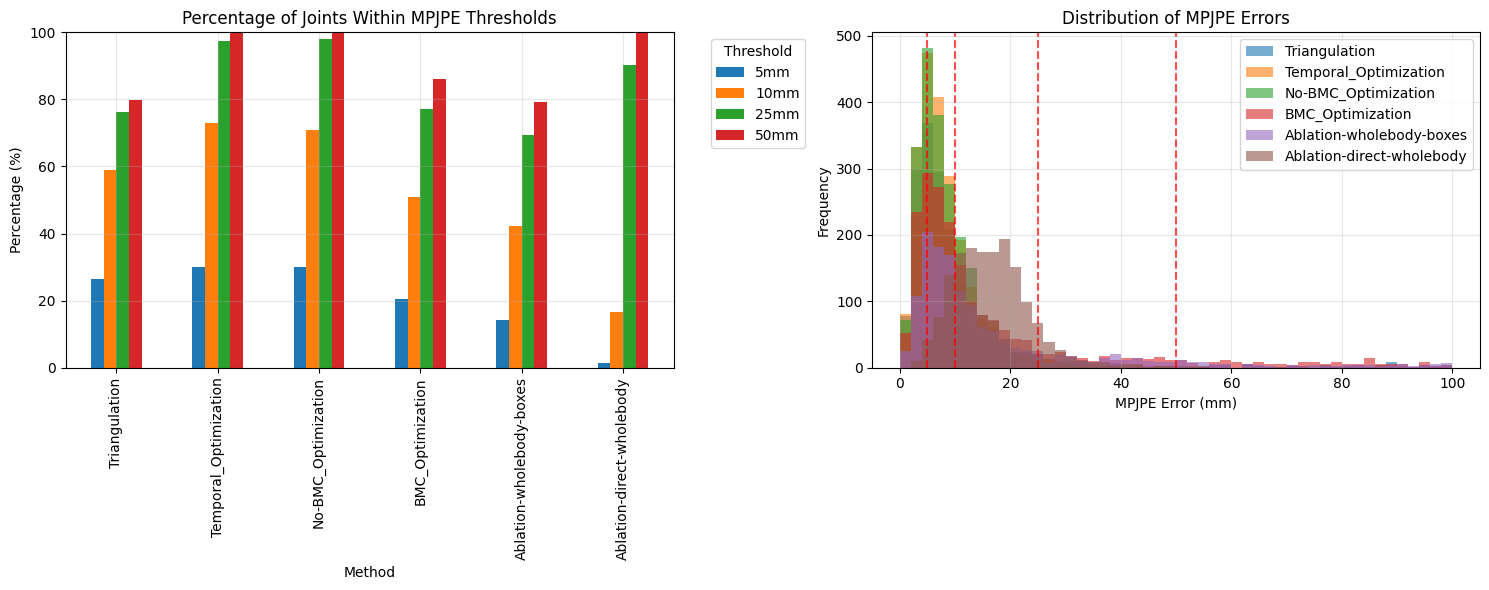


=== MPJPE Error Statistics (Averaged Across Data Collections) ===


,Method,Mean Error (mm),Median Error (mm),Std Error (mm),Min Error (mm),Max Error (mm),95th Percentile (mm)
0,Triangulation,111.091385,8.138147,278.673875,0.437112,1558.032174,848.399300
1,Temporal_Optimization,8.449193,6.885555,6.230273,0.878794,54.958686,19.502040
2,No-BMC_Optimization,8.475201,6.989439,5.912692,0.709133,54.506402,19.063204
3,BMC_Optimization,27.885373,10.219757,43.022409,0.275163,300.258160,123.916398
4,Ablation-wholebody-boxes,36.987887,12.028843,54.457612,0.729782,301.386923,170.906211
5,Ablation-direct-wholebody,16.706113,16.071280,7.138424,2.704926,68.980165,28.463791


{'Triangulation': {'cha/cha1': 73.94957983193278, 'cha/cha2': 61.92660550458716, 'cha/cha3': 55.02136752136752, 'cha/cha4': 76.5, 'cha/cha5': 48.71134020618557, 'cha/cha6': 60.43577981651376, 'cha/cha7': 54.929577464788736, 'chb/chb1': 72.49103942652329, 'chb/chb2': 39.32584269662921}, 'Temporal_Optimization': {'cha/cha1': 76.15546218487395, 'cha/cha2': 72.94520547945206, 'cha/cha3': 73.72881355932203, 'cha/cha4': 77.7, 'cha/cha5': 71.86046511627907, 'cha/cha6': 74.43438914027149, 'cha/cha7': 80.41125541125541, 'chb/chb1': 77.23214285714286, 'chb/chb2': 71.14695340501792}, 'No-BMC_Optimization': {'cha/cha1': 76.05042016806723, 'cha/cha2': 70.662100456621, 'cha/cha3': 71.82203389830508, 'cha/cha4': 77.19999999999999, 'cha/cha5': 71.74418604651163, 'cha/cha6': 73.98190045248869, 'cha/cha7': 79.76190476190476, 'chb/chb1': 77.5, 'chb/chb2': 73.38709677419355}, 'BMC_Optimization': {'cha/cha1': 70.69327731092437, 'cha/cha2': 59.93150684931507, 'cha/cha3': 66.52542372881356, 'cha/cha4': 67.2,

In [18]:
# Define MPJPE thresholds to evaluate (in millimeters)
mpjpe_thresholds = [5, 10, 25, 50]

# Initialize aggregated results
mpjpe_threshold_results_aggregated = defaultdict(list)
all_joint_errors_aggregated = defaultdict(list)
mean_pck3d = {}

for data_collection in data_collections:
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    # triangulated_poses_array = triangulate_3d_poses(labeled_2d_poses, cam_intrinsics, cam_extrinsics, hand_3d_poses)
    all_joint_errors_by_method, mpjpe_threshold_results = report_results_3(hand_3d_poses, labeled_3d_poses, mpjpe_thresholds)

    # Aggregate results
    for method, results in mpjpe_threshold_results.items():
        percentages = []
        for threshold, percentage in results.items():
            mpjpe_threshold_results_aggregated[(method, threshold)].append(percentage)
            percentages.append(percentage)

        if method not in mean_pck3d:
            mean_pck3d[method] = {}
        mean_pck3d[method][data_collection] = np.mean(percentages) if len(percentages) > 0 else np.nan

    for method, errors in all_joint_errors_by_method.items():
        all_joint_errors_aggregated[method].extend(errors)

for data_collection in data_collections_chb:
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    # triangulated_poses_array = triangulate_3d_poses(labeled_2d_poses, cam_intrinsics, cam_extrinsics, hand_3d_poses)
    all_joint_errors_by_method, mpjpe_threshold_results = report_results_3(hand_3d_poses, labeled_3d_poses, mpjpe_thresholds)

    # Aggregate results
    for method, results in mpjpe_threshold_results.items():
        percentages = []
        for threshold, percentage in results.items():
            mpjpe_threshold_results_aggregated[(method, threshold)].append(percentage)
            percentages.append(percentage)

        if method not in mean_pck3d:
            mean_pck3d[method] = {}
        mean_pck3d[method][data_collection] = np.mean(percentages) if len(percentages) > 0 else np.nan

    for method, errors in all_joint_errors_by_method.items():
        all_joint_errors_aggregated[method].extend(errors)

        

print(mpjpe_threshold_results_aggregated)

# Average the results across all data collections
mpjpe_threshold_results_avg = {}
for (method, threshold), percentages in mpjpe_threshold_results_aggregated.items():
    if method not in mpjpe_threshold_results_avg:
        mpjpe_threshold_results_avg[method] = {}
    mpjpe_threshold_results_avg[method][threshold] = np.mean(percentages)

method_mean_reconstruction_percentage = {}
for method, values in mpjpe_threshold_results_avg.items():
    method_mean_reconstruction_percentage[method] = np.mean(list(values.values()))

# Create MPJPE threshold analysis results table
mpjpe_threshold_df_data = []
for method in mpjpe_threshold_results_avg:
    row = {'Method': method}
    row.update({f'{threshold}mm': mpjpe_threshold_results_avg[method][f'{threshold}mm'] for threshold in mpjpe_thresholds})
    row.update({'Mean Reconstruction Percentage': method_mean_reconstruction_percentage[method]})
    mpjpe_threshold_df_data.append(row)

mpjpe_threshold_df = pd.DataFrame(mpjpe_threshold_df_data)
print("\n=== Percentage of Joints Within MPJPE Thresholds (Averaged Across Data Collections) ===")
display(mpjpe_threshold_df)

# Visualization of MPJPE threshold analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot showing percentage within each MPJPE threshold
mpjpe_threshold_cols = [f'{t}mm' for t in mpjpe_thresholds]
mpjpe_threshold_df.set_index('Method')[mpjpe_threshold_cols].plot(kind='bar', ax=axes[0], 
                                                                 title='Percentage of Joints Within MPJPE Thresholds',
                                                                 ylabel='Percentage (%)',
                                                                 xlabel='Method')
axes[0].legend(title='Threshold', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

# MPJPE error distribution histograms
for method, errors in all_joint_errors_aggregated.items():
    if len(errors) > 0:
        axes[1].hist(errors, bins=50, alpha=0.6, label=method, range=(0, 100))

axes[1].set_xlabel('MPJPE Error (mm)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of MPJPE Errors')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Add vertical lines for thresholds
for threshold in mpjpe_thresholds:
    axes[1].axvline(x=threshold, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# MPJPE Error Statistics
print("\n=== MPJPE Error Statistics (Averaged Across Data Collections) ===")
mpjpe_stats_data = []
for method, errors in all_joint_errors_aggregated.items():
    if len(errors) > 0:
        mpjpe_stats_data.append({
            'Method': method,
            'Mean Error (mm)': np.mean(errors),
            'Median Error (mm)': np.median(errors),
            'Std Error (mm)': np.std(errors),
            'Min Error (mm)': np.min(errors),
            'Max Error (mm)': np.max(errors),
            '95th Percentile (mm)': np.percentile(errors, 95)
        })

mpjpe_stats_df = pd.DataFrame(mpjpe_stats_data)

display(mpjpe_stats_df)
print(mean_pck3d)

## L0 MPJPE

In [19]:
# Define MPJPE thresholds to evaluate (in millimeters)
mpjpe_thresholds = [5, 10, 25, 50]

# Initialize aggregated results
mpjpe_threshold_results_aggregated = defaultdict(list)
all_joint_errors_aggregated = defaultdict(list)
mean_pck3d = {}

data_collections = [f'{dataset}/cha1', f'{dataset}/cha5', f'{dataset}/cha6', f'{dataset}/cha7']  # dataset collection name


for data_collection in data_collections:
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    # triangulated_poses_array = triangulate_3d_poses(labeled_2d_poses, cam_intrinsics, cam_extrinsics, hand_3d_poses)
    all_joint_errors_by_method, mpjpe_threshold_results = report_results_3(hand_3d_poses, labeled_3d_poses, mpjpe_thresholds)

    # Aggregate results
    for method, results in mpjpe_threshold_results.items():
        percentages = []
        for threshold, percentage in results.items():
            mpjpe_threshold_results_aggregated[(method, threshold)].append(percentage)
            percentages.append(percentage)

        if method not in mean_pck3d:
            mean_pck3d[method] = {}
        mean_pck3d[method][data_collection] = np.mean(percentages) if len(percentages) > 0 else np.nan

    for method, errors in all_joint_errors_by_method.items():
        all_joint_errors_aggregated[method].extend(errors)

print(mpjpe_threshold_results_aggregated)

# Average the results across all data collections
mpjpe_threshold_results_avg = {}
for (method, threshold), percentages in mpjpe_threshold_results_aggregated.items():
    if method not in mpjpe_threshold_results_avg:
        mpjpe_threshold_results_avg[method] = {}
    mpjpe_threshold_results_avg[method][threshold] = np.mean(percentages)

method_mean_reconstruction_percentage = {}
for method, values in mpjpe_threshold_results_avg.items():
    method_mean_reconstruction_percentage[method] = np.mean(list(values.values()))

# Create MPJPE threshold analysis results table
mpjpe_threshold_df_data = []
for method in mpjpe_threshold_results_avg:
    row = {'Method': method}
    row.update({f'{threshold}mm': mpjpe_threshold_results_avg[method][f'{threshold}mm'] for threshold in mpjpe_thresholds})
    row.update({'Mean Reconstruction Percentage': method_mean_reconstruction_percentage[method]})
    mpjpe_threshold_df_data.append(row)

mpjpe_threshold_df = pd.DataFrame(mpjpe_threshold_df_data)
print("\n=== Percentage of Joints Within MPJPE Thresholds (Averaged Across Data Collections) ===")
display(mpjpe_threshold_df)

print(mean_pck3d)

Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-wholebody-boxes': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-direct-wholebody': (10, 42, 3)
=== MPJPE Threshold Analysis ===

Analyzing Triangulation...
  Total joints analyzed: 238
  Joints within 5mm: 31.5%
  Joints within 10mm: 73.9%
  Joints within 25mm: 93.7%
  Joints within 50mm: 96.6%

Analyzing Temporal_Optimization...
  Total joints analyzed: 238
  Joints within 5mm: 33.6%
  Joints within 10mm: 74.4%
  Joints within 25mm: 97.1%
  Joints within 50mm: 99.6%

Analyzing No-BMC_Optimization...
  Total joints analyzed: 238
  Joints within 5mm: 32.4%
  Joints within 10mm: 75.6%
  Joints within 25mm: 96.2%
  Joints within 50mm: 100.0

,Method,5mm,10mm,25mm,50mm,Mean Reconstruction Percentage
0,Triangulation,25.829015,60.235199,74.592378,77.369685,59.506569
1,Temporal_Optimization,31.297888,73.436164,98.232562,99.894958,75.715393
2,No-BMC_Optimization,30.549862,72.733514,98.255036,100.000000,75.384603
3,BMC_Optimization,27.317800,67.104548,94.426686,97.643305,71.623085
4,Ablation-wholebody-boxes,10.163069,32.068257,57.878600,70.778717,42.722161
5,Ablation-direct-wholebody,1.323108,16.606548,94.018857,99.891775,52.960072


{'Triangulation': {'cha/cha1': 73.94957983193278, 'cha/cha5': 48.71134020618557, 'cha/cha6': 60.43577981651376, 'cha/cha7': 54.929577464788736}, 'Temporal_Optimization': {'cha/cha1': 76.15546218487395, 'cha/cha5': 71.86046511627907, 'cha/cha6': 74.43438914027149, 'cha/cha7': 80.41125541125541}, 'No-BMC_Optimization': {'cha/cha1': 76.05042016806723, 'cha/cha5': 71.74418604651163, 'cha/cha6': 73.98190045248869, 'cha/cha7': 79.76190476190476}, 'BMC_Optimization': {'cha/cha1': 70.69327731092437, 'cha/cha5': 67.7906976744186, 'cha/cha6': 71.49321266968326, 'cha/cha7': 76.51515151515153}, 'Ablation-wholebody-boxes': {'cha/cha1': 68.80252100840336, 'cha/cha5': 21.86046511627907, 'cha/cha6': 68.21266968325791, 'cha/cha7': 12.012987012987011}, 'Ablation-direct-wholebody': {'cha/cha1': 51.57563025210084, 'cha/cha5': 53.604651162790695, 'cha/cha6': 53.84615384615385, 'cha/cha7': 52.81385281385282}}


## L1 MPJPE

In [20]:
# Define MPJPE thresholds to evaluate (in millimeters)
mpjpe_thresholds = [5, 10, 25, 50]

# Initialize aggregated results
mpjpe_threshold_results_aggregated = defaultdict(list)
all_joint_errors_aggregated = defaultdict(list)
mean_pck3d = {}

data_collections = [f'{dataset}/cha2', f'{dataset}/cha3', f'{dataset}/cha4']  # dataset collection name


for data_collection in data_collections:
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    # triangulated_poses_array = triangulate_3d_poses(labeled_2d_poses, cam_intrinsics, cam_extrinsics, hand_3d_poses)
    all_joint_errors_by_method, mpjpe_threshold_results = report_results_3(hand_3d_poses, labeled_3d_poses, mpjpe_thresholds)

    # Aggregate results
    for method, results in mpjpe_threshold_results.items():
        percentages = []
        for threshold, percentage in results.items():
            mpjpe_threshold_results_aggregated[(method, threshold)].append(percentage)
            percentages.append(percentage)

        if method not in mean_pck3d:
            mean_pck3d[method] = {}
        mean_pck3d[method][data_collection] = np.mean(percentages) if len(percentages) > 0 else np.nan

    for method, errors in all_joint_errors_by_method.items():
        all_joint_errors_aggregated[method].extend(errors)

print(mpjpe_threshold_results_aggregated)

# Average the results across all data collections
mpjpe_threshold_results_avg = {}
for (method, threshold), percentages in mpjpe_threshold_results_aggregated.items():
    if method not in mpjpe_threshold_results_avg:
        mpjpe_threshold_results_avg[method] = {}
    mpjpe_threshold_results_avg[method][threshold] = np.mean(percentages)

method_mean_reconstruction_percentage = {}
for method, values in mpjpe_threshold_results_avg.items():
    method_mean_reconstruction_percentage[method] = np.mean(list(values.values()))

# Create MPJPE threshold analysis results table
mpjpe_threshold_df_data = []
for method in mpjpe_threshold_results_avg:
    row = {'Method': method}
    row.update({f'{threshold}mm': mpjpe_threshold_results_avg[method][f'{threshold}mm'] for threshold in mpjpe_thresholds})
    row.update({'Mean Reconstruction Percentage': method_mean_reconstruction_percentage[method]})
    mpjpe_threshold_df_data.append(row)

mpjpe_threshold_df = pd.DataFrame(mpjpe_threshold_df_data)
print("\n=== Percentage of Joints Within MPJPE Thresholds (Averaged Across Data Collections) ===")
display(mpjpe_threshold_df)

print(mean_pck3d)

Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-wholebody-boxes': (10, 42, 3)
Loaded 3D hand poses for method 'Ablation-direct-wholebody': (10, 42, 3)
=== MPJPE Threshold Analysis ===

Analyzing Triangulation...
  Total joints analyzed: 218
  Joints within 5mm: 18.8%
  Joints within 10mm: 56.4%
  Joints within 25mm: 82.1%
  Joints within 50mm: 90.4%

Analyzing Temporal_Optimization...
  Total joints analyzed: 219
  Joints within 5mm: 26.0%
  Joints within 10mm: 68.9%
  Joints within 25mm: 96.8%
  Joints within 50mm: 100.0%

Analyzing No-BMC_Optimization...
  Total joints analyzed: 219
  Joints within 5mm: 22.4%
  Joints within 10mm: 62.1%
  Joints within 25mm: 98.2%
  Joints within 50mm: 100.

,Method,5mm,10mm,25mm,50mm,Mean Reconstruction Percentage
0,Triangulation,25.418971,60.237539,82.856070,89.418051,64.482658
1,Temporal_Optimization,28.923257,74.092862,96.565059,99.584181,74.791340
2,No-BMC_Optimization,27.940629,68.522751,96.864618,99.584181,73.228045
3,BMC_Optimization,22.308371,52.415138,86.364863,97.120868,64.552310
4,Ablation-wholebody-boxes,19.824967,55.976085,84.710007,90.523602,62.758665
5,Ablation-direct-wholebody,1.661476,16.519795,85.447349,99.706550,50.833793


{'Triangulation': {'cha/cha2': 61.92660550458716, 'cha/cha3': 55.02136752136752, 'cha/cha4': 76.5}, 'Temporal_Optimization': {'cha/cha2': 72.94520547945206, 'cha/cha3': 73.72881355932203, 'cha/cha4': 77.7}, 'No-BMC_Optimization': {'cha/cha2': 70.662100456621, 'cha/cha3': 71.82203389830508, 'cha/cha4': 77.19999999999999}, 'BMC_Optimization': {'cha/cha2': 59.93150684931507, 'cha/cha3': 66.52542372881356, 'cha/cha4': 67.2}, 'Ablation-wholebody-boxes': {'cha/cha2': 56.278538812785385, 'cha/cha3': 69.59745762711864, 'cha/cha4': 62.4}, 'Ablation-direct-wholebody': {'cha/cha2': 50.91324200913242, 'cha/cha3': 49.788135593220346, 'cha/cha4': 51.8}}


## L2 MPJPE

In [21]:
# Define MPJPE thresholds to evaluate (in millimeters)
mpjpe_thresholds = [5, 10, 20, 30]

# Initialize aggregated results
mpjpe_threshold_results_aggregated = defaultdict(list)
all_joint_errors_aggregated = defaultdict(list)
mean_pck3d = {}

data_collections = [f'chb/chb1', f'chb/chb2']  # dataset collection name


for data_collection in data_collections:
    labeled_2d_poses, labeled_3d_poses, hand_3d_poses = load_data(data_collection)
    # triangulated_poses_array = triangulate_3d_poses(labeled_2d_poses, cam_intrinsics, cam_extrinsics, hand_3d_poses)
    all_joint_errors_by_method, mpjpe_threshold_results = report_results_3(hand_3d_poses, labeled_3d_poses, mpjpe_thresholds)

    # Aggregate results
    for method, results in mpjpe_threshold_results.items():
        percentages = []
        for threshold, percentage in results.items():
            mpjpe_threshold_results_aggregated[(method, threshold)].append(percentage)
            percentages.append(percentage)

        if method not in mean_pck3d:
            mean_pck3d[method] = {}
        mean_pck3d[method][data_collection] = np.mean(percentages) if len(percentages) > 0 else np.nan

    for method, errors in all_joint_errors_by_method.items():
        all_joint_errors_aggregated[method].extend(errors)

print(mpjpe_threshold_results_aggregated)

# Average the results across all data collections
mpjpe_threshold_results_avg = {}
for (method, threshold), percentages in mpjpe_threshold_results_aggregated.items():
    if method not in mpjpe_threshold_results_avg:
        mpjpe_threshold_results_avg[method] = {}
    mpjpe_threshold_results_avg[method][threshold] = np.mean(percentages)

method_mean_reconstruction_percentage = {}
for method, values in mpjpe_threshold_results_avg.items():
    method_mean_reconstruction_percentage[method] = np.mean(list(values.values()))

# Create MPJPE threshold analysis results table
mpjpe_threshold_df_data = []
for method in mpjpe_threshold_results_avg:
    row = {'Method': method}
    row.update({f'{threshold}mm': mpjpe_threshold_results_avg[method][f'{threshold}mm'] for threshold in mpjpe_thresholds})
    row.update({'Mean Reconstruction Percentage': method_mean_reconstruction_percentage[method]})
    mpjpe_threshold_df_data.append(row)

mpjpe_threshold_df = pd.DataFrame(mpjpe_threshold_df_data)
print("\n=== Percentage of Joints Within MPJPE Thresholds (Averaged Across Data Collections) ===")
display(mpjpe_threshold_df)

print(mean_pck3d)

Loaded labeled 2D hand poses for 10 frames.
Loaded 3D hand poses for method 'Triangulation': (10, 42, 3)
Loaded 3D hand poses for method 'Temporal_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'No-BMC_Optimization': (10, 42, 3)
Loaded 3D hand poses for method 'BMC_Optimization': (10, 42, 3)
Failed to load 3D hand poses for method 'Ablation-wholebody-boxes'
Failed to load 3D hand poses for method 'Ablation-direct-wholebody'
=== MPJPE Threshold Analysis ===

Analyzing Triangulation...
  Total joints analyzed: 279
  Joints within 5mm: 38.0%
  Joints within 10mm: 70.3%
  Joints within 20mm: 89.2%
  Joints within 30mm: 90.3%

Analyzing Temporal_Optimization...
  Total joints analyzed: 280
  Joints within 5mm: 33.9%
  Joints within 10mm: 77.1%
  Joints within 20mm: 96.8%
  Joints within 30mm: 98.6%

Analyzing No-BMC_Optimization...
  Total joints analyzed: 280
  Joints within 5mm: 34.6%
  Joints within 10mm: 77.1%
  Joints within 20mm: 97.1%
  Joints within 30mm: 99.6%

Analyzin

,Method,5mm,10mm,20mm,30mm,Mean Reconstruction Percentage
0,Triangulation,29.296041,54.226572,67.844630,69.505860,55.218276
1,Temporal_Optimization,29.150666,70.291859,94.808628,98.568868,73.205005
2,No-BMC_Optimization,31.658346,71.367127,96.779314,99.463006,74.816948
3,BMC_Optimization,3.751280,16.260241,26.271761,31.465054,19.437084


{'Triangulation': {'chb/chb1': 71.95340501792114, 'chb/chb2': 38.48314606741573}, 'Temporal_Optimization': {'chb/chb1': 76.60714285714286, 'chb/chb2': 69.80286738351253}, 'No-BMC_Optimization': {'chb/chb1': 77.14285714285714, 'chb/chb2': 72.4910394265233}, 'BMC_Optimization': {'chb/chb1': 29.107142857142858, 'chb/chb2': 9.767025089605735}}


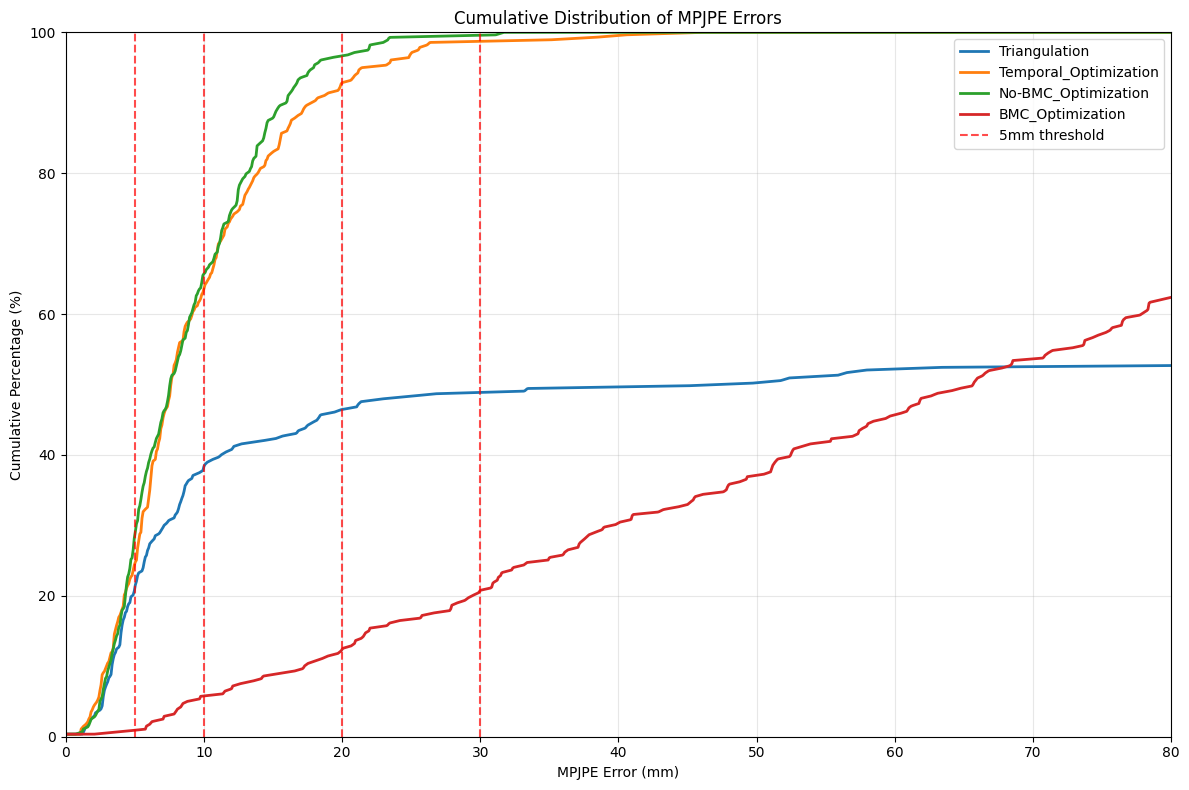


=== Comparative Analysis at Key MPJPE Thresholds ===

At 5mm threshold:
  1. No-BMC_Optimization: 28.7%
  2. Temporal_Optimization: 24.4%
  3. Triangulation: 20.6%
  4. BMC_Optimization: 0.7%

At 10mm threshold:
  1. No-BMC_Optimization: 65.6%
  2. Temporal_Optimization: 63.4%
  3. Triangulation: 38.2%
  4. BMC_Optimization: 5.7%

At 20mm threshold:
  1. No-BMC_Optimization: 96.4%
  2. Temporal_Optimization: 92.8%
  3. Triangulation: 46.4%
  4. BMC_Optimization: 12.2%

At 30mm threshold:
  1. No-BMC_Optimization: 99.3%
  2. Temporal_Optimization: 98.6%
  3. Triangulation: 48.7%
  4. BMC_Optimization: 20.4%

=== Best Performing Method at Each MPJPE Threshold ===
At 5mm: No-BMC_Optimization (28.7%)
At 10mm: No-BMC_Optimization (65.6%)
At 20mm: No-BMC_Optimization (96.4%)
At 30mm: No-BMC_Optimization (99.3%)

=== Combined Threshold Analysis Summary ===
This compares both reprojection (2D) and MPJPE (3D) threshold performance:


,Method,Reproj_5px,Reproj_10px,Reproj_20px,Reproj_30px,MPJPE_5mm,MPJPE_10mm,MPJPE_20mm,MPJPE_30mm
0,Triangulation,33.070866,55.690766,65.139585,68.217609,20.599251,38.202247,46.441948,48.689139
1,Temporal_Optimization,45.239800,80.171797,98.067287,99.713672,24.372760,63.440860,92.831541,98.566308
2,No-BMC_Optimization,43.879742,78.239084,97.780959,99.642090,28.673835,65.591398,96.415771,99.283154
3,BMC_Optimization,43.235505,74.588404,93.987115,96.850394,0.716846,5.734767,12.186380,20.430108


In [22]:
# MPJPE Cumulative Distribution Function (CDF) Analysis
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

max_error_to_plot = 80  # Focus on errors up to 80mm
x_values = np.linspace(0, max_error_to_plot, 1000)

for method, errors in all_joint_errors_by_method.items():
    if len(errors) > 0:
        # Calculate CDF
        errors_sorted = np.sort(errors)
        cdf_values = np.arange(1, len(errors_sorted) + 1) / len(errors_sorted) * 100
        
        # Interpolate for smooth curve
        cdf_interp = np.interp(x_values, errors_sorted, cdf_values)
        ax.plot(x_values, cdf_interp, label=method, linewidth=2)

# Add threshold lines
for threshold in mpjpe_thresholds:
    ax.axvline(x=threshold, color='red', linestyle='--', alpha=0.7, 
               label=f'{threshold}mm threshold' if threshold == mpjpe_thresholds[0] else '')

ax.set_xlabel('MPJPE Error (mm)')
ax.set_ylabel('Cumulative Percentage (%)')
ax.set_title('Cumulative Distribution of MPJPE Errors')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max_error_to_plot)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Comparative analysis at specific MPJPE thresholds
print("\n=== Comparative Analysis at Key MPJPE Thresholds ===")
for threshold in mpjpe_thresholds:
    print(f"\nAt {threshold}mm threshold:")
    threshold_key = f'{threshold}mm'
    
    # Sort methods by performance at this threshold
    method_performance = [(method, mpjpe_threshold_results[method][threshold_key]) 
                         for method in mpjpe_threshold_results.keys()]
    method_performance.sort(key=lambda x: x[1], reverse=True)
    
    for i, (method, percentage) in enumerate(method_performance, 1):
        print(f"  {i}. {method}: {percentage:.1f}%")

# Best performing method at each MPJPE threshold
print("\n=== Best Performing Method at Each MPJPE Threshold ===")
for threshold in mpjpe_thresholds:
    threshold_key = f'{threshold}mm'
    best_method = max(mpjpe_threshold_results.keys(), 
                     key=lambda m: mpjpe_threshold_results[m][threshold_key])
    best_percentage = mpjpe_threshold_results[best_method][threshold_key]
    print(f"At {threshold}mm: {best_method} ({best_percentage:.1f}%)")

# Combined threshold analysis comparison
print("\n=== Combined Threshold Analysis Summary ===")
print("This compares both reprojection (2D) and MPJPE (3D) threshold performance:")

combined_summary = []
for method in hand_3d_poses:
    row = {'Method': method}
    
    # Add reprojection thresholds
    if method in threshold_results:
        for threshold in thresholds:
            row[f'Reproj_{threshold}px'] = threshold_results[method][f'{threshold}px']
    
    # Add MPJPE thresholds
    if method in mpjpe_threshold_results:
        for threshold in mpjpe_thresholds:
            row[f'MPJPE_{threshold}mm'] = mpjpe_threshold_results[method][f'{threshold}mm']
    
    combined_summary.append(row)

combined_df = pd.DataFrame(combined_summary)
display(combined_df)